# Arrehnius and Modified Arrhenius

In [1]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from diffPLOG2TROE.parametrization import Arrhenius

This tutorial demonstrates the computation of kinetic rate constants for a simple Arrhenius reaction across a specified temperature range. The implementation focuses solely on the forward reaction rate constant, as determined by user-provided parameters. Note that this code does not incorporate chemical equilibrium calculations, thus considering only unidirectional reaction kinetics.
- Equation
    > $k_f(T) = A \: T^n \: exp\left(\frac{Eact}{RT}\right)$
- CHEMKIN representation
    >```
    >H2 + O = H + OH    +5.080E+04 +2.670E+00 +6.292E+03
    >```
- Internal representation of the rate constant can be done in different ways:
  1. As a python dictionary, passing directly the dictionary to the Arrhenius object
     
    >```python
    >rate_constant = {
    >    "name": "H2+O=H+OH",
    >    "type": "arrhenius",
    >    "rate-constant": {
    >        "coefficients": [5.080e+04, 2.670E+00, 6.292e+03]
    >    }
    >}
    >rate_constant = Arrhenius(rate_constant_dictionary)
    >```

  2. As a python array (keep in mind that in this case the name is optional and can be omitted), passing directly the list of parameters to the Arrhenius object
     
    >```python
    >rate_constant = Arrhenius(name="H2+O=H+OH", params=[5.080e+04, 2.670E+00, 6.292e+03])
    >```

In [2]:
# --------------------------------------------------------
# Direct parameters initialization
# --------------------------------------------------------
rate_constant = Arrhenius(name="H2+O=H+OH", parameters=[5.080e+04, 2.670E+00, 6.292e+03])

## Kinetic constant computation

After initializing the rate constant correctly, we gain access to the methods specific to the Arrhenius object, including the calculation of the kinetic constant across different temperature ranges. Keep in mind that the standard or modified arrhenius expression express the kinetic constant only as a temperature dependent function.

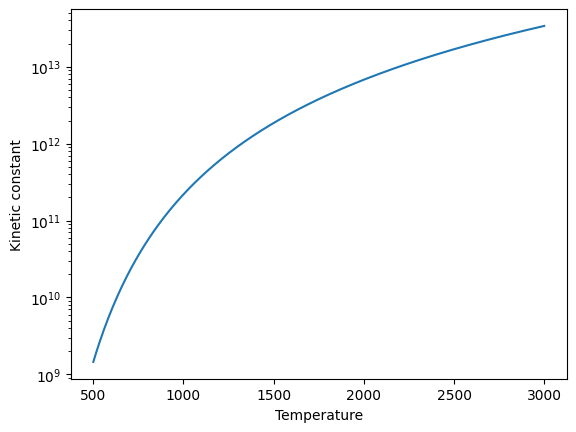

In [3]:
# --------------------------------------------------------
# Rate constant initialization
# --------------------------------------------------------
rate_constant = Arrhenius(parameters=[5.080e+04, 2.670E+00, 6.292e+03])

# --------------------------------------------------------
# Compute the kinetic constant
# --------------------------------------------------------
T_range = jnp.linspace(500, 3000, 300)
kinetic_constant = rate_constant.kinetic_constant(T_range)

# Let's visualize it
plt.semilogy(T_range, kinetic_constant)
plt.xlabel("Temperature")
plt.ylabel("Kinetic constant")
plt.show()

When analyzing reaction kinetics, you often have experimental data of reaction rate constants measured at different temperatures rather than pre-determined Arrhenius parameters. The `Arrhenius.from_data` method provides a convenient way to fit your experimental data to the Arrhenius equation directly.

The Arrhenius equation can be expressed in different forms:

- Two-parameter form: $k_f(T) = A \: exp\left(\frac{Eact}{RT}\right)$
- Three-parameter form: $k_f(T) = A \: T^n \: exp\left(\frac{Eact}{RT}\right)$

The `from_data` classmethod performs a least-squares regression on the logarithmic form of the equation:

- $ln⁡(k)=ln⁡(A)+n \: ln⁡(T)−\frac{Ea}{R} \: \frac{1}{T}$

This allows for fitting: Pre-exponential factor (A), Temperature exponent (n) - optional, set to 0 for two-parameter model, Activation energy (Ea).

In [8]:
import numpy as np
import jax.numpy as jnp
from diffPLOG2TROE.utilities.physical_constants import constants


def analyze_fit_results(fitted_arrhenius, fit_results, temps, rates, true_params=None):
    """
    Comprehensive analysis of Arrhenius fitting results
    
    Parameters:
    -----------
    fitted_arrhenius : Arrhenius object
    fit_results : dict with fitting statistics
    temps : array of temperatures
    rates : array of rate constants  
    true_params : optional [A_true, n_true, Ea_true] for synthetic data
    """
    
    print("="*60)
    print("ARRHENIUS FITTING RESULTS ANALYSIS")
    print("="*60)
    
    # Extract fitted parameters (transform from fitted space to physical space)
    A_fitted = jnp.exp(fitted_arrhenius.lnA)  # exp(ln(A)) → A
    n_fitted = fitted_arrhenius.n              # n (no transformation)
    Ea_fitted = fitted_arrhenius.EaR * constants.R_cal_mol  # (Ea/R) × R → Ea
    
    # Transform uncertainties using error propagation
    # IMPORTANT: fit_results contains uncertainties in [ln(A), n, Ea/R], not [A, n, Ea]!
    A_uncertainty = A_fitted * fit_results['lnA_uncertainty']  # σ_A = A × σ_lnA
    n_uncertainty = fit_results['n_uncertainty']               # σ_n = σ_n (direct)
    Ea_uncertainty = fit_results['EaR_uncertainty'] * constants.R_cal_mol  # σ_Ea = R × σ_EaR
    
    print(f"\n1. FITTED PARAMETERS WITH UNCERTAINTIES:")
    print("-" * 40)
    print(f"Pre-exponential factor A: {A_fitted:.2e} ± {A_uncertainty:.2e}")
    print(f"Temperature exponent n:   {n_fitted:.4f} ± {n_uncertainty:.4f}")
    print(f"Activation energy Ea:     {Ea_fitted:.0f} ± {Ea_uncertainty:.0f} cal/mol")
    
    print(f"\n   Raw fitted parameters (what was actually optimized):")
    print(f"   ln(A): {fitted_arrhenius.lnA:.3f} ± {fit_results['lnA_uncertainty']:.3f}")
    print(f"   n:     {fitted_arrhenius.n:.4f} ± {fit_results['n_uncertainty']:.4f}")
    print(f"   Ea/R:  {fitted_arrhenius.EaR:.1f} ± {fit_results['EaR_uncertainty']:.1f} K")
    
    # Relative uncertainties (as percentages)
    rel_A = (A_uncertainty / A_fitted) * 100
    rel_n = (n_uncertainty / abs(n_fitted)) * 100 if n_fitted != 0 else float('inf')
    rel_Ea = (Ea_uncertainty / Ea_fitted) * 100
    
    print(f"\nRelative uncertainties:")
    print(f"A:  {rel_A:.1f}%")
    print(f"n:  {rel_n:.1f}%")  
    print(f"Ea: {rel_Ea:.1f}%")
    
    # Compare with true values if provided
    if true_params is not None:
        A_true, n_true, Ea_true = true_params
        print(f"\n2. COMPARISON WITH TRUE VALUES:")
        print("-" * 40)
        print(f"A:  fitted={A_fitted:.2e}, true={A_true:.2e}, error={abs(A_fitted-A_true)/A_true*100:.1f}%")
        print(f"n:  fitted={n_fitted:.4f}, true={n_true:.4f}, error={abs(n_fitted-n_true)/abs(n_true)*100:.1f}%")
        print(f"Ea: fitted={Ea_fitted:.0f}, true={Ea_true:.0f}, error={abs(Ea_fitted-Ea_true)/Ea_true*100:.1f}%")
    
    # Goodness of fit metrics
    log_rates = jnp.log(rates)
    y_mean = jnp.mean(log_rates)
    TSS = jnp.sum((log_rates - y_mean)**2)
    R_squared = 1 - fit_results['RSS'] / TSS
    RMSE_log = jnp.sqrt(fit_results['RSS'] / fit_results['DoF'])
    
    print(f"\n3. GOODNESS OF FIT:")
    print("-" * 40)
    print(f"R-squared:              {R_squared:.4f}")
    print(f"RMSE (log space):       {RMSE_log:.4f}")
    print(f"Residual Sum of Squares: {fit_results['RSS']:.3f}")
    print(f"Degrees of Freedom:     {fit_results['DoF']}")
    
    # Interpretation
    print(f"\n4. QUALITY ASSESSMENT:")
    print("-" * 40)
    
    quality_score = 0
    if R_squared > 0.99: 
        print("✓ Excellent fit (R² > 0.99)")
        quality_score += 2
    elif R_squared > 0.95:
        print("✓ Good fit (R² > 0.95)")
        quality_score += 1
    else:
        print("⚠ Poor fit (R² < 0.95)")
    
    if RMSE_log < 0.05:
        print("✓ Very low prediction error")
        quality_score += 2
    elif RMSE_log < 0.1:
        print("✓ Low prediction error")
        quality_score += 1
    else:
        print("⚠ High prediction error")
    
    if max(rel_A, rel_n, rel_Ea) < 10:
        print("✓ Low parameter uncertainties")
        quality_score += 2
    elif max(rel_A, rel_n, rel_Ea) < 20:
        print("✓ Moderate parameter uncertainties")
        quality_score += 1
    else:
        print("⚠ High parameter uncertainties")
    
    print(f"\nOverall Quality Score: {quality_score}/6")
    
    if quality_score >= 5:
        print("🎯 Excellent fit - parameters are reliable")
    elif quality_score >= 3:
        print("👍 Good fit - parameters are reasonably reliable")
    else:
        print("⚠️  Poor fit - consider more data or different model")
    
    return {
        'fitted_params': [A_fitted, n_fitted, Ea_fitted],
        'uncertainties': [A_uncertainty, n_uncertainty, Ea_uncertainty],
        'relative_uncertainties': [rel_A, rel_n, rel_Ea],
        'R_squared': R_squared,
        'RMSE_log': RMSE_log,
        'quality_score': quality_score
    }

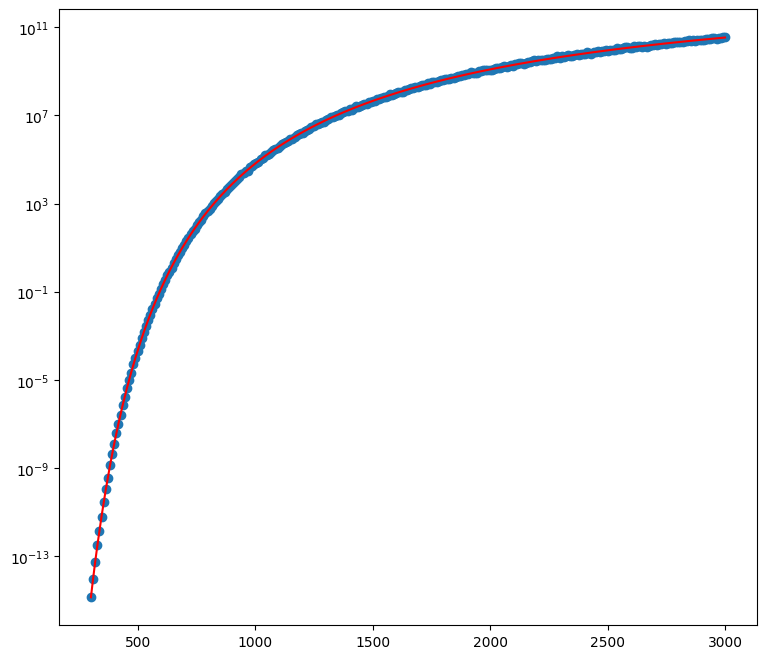

ARRHENIUS FITTING RESULTS ANALYSIS

1. FITTED PARAMETERS WITH UNCERTAINTIES:
----------------------------------------
Pre-exponential factor A: 2.18e+12 ± 2.78e+11
Temperature exponent n:   0.2822 ± 0.0158
Activation energy Ea:     38286 ± 30 cal/mol

   Raw fitted parameters (what was actually optimized):
   ln(A): 28.410 ± 0.127
   n:     0.2822 ± 0.0158
   Ea/R:  19266.5 ± 14.9 K

Relative uncertainties:
A:  12.7%
n:  5.6%
Ea: 0.1%

2. COMPARISON WITH TRUE VALUES:
----------------------------------------
A:  fitted=2.18e+12, true=2.40e+12, error=9.2%
n:  fitted=0.2822, true=0.2700, error=4.5%
Ea: fitted=38286, true=38300, error=0.0%

3. GOODNESS OF FIT:
----------------------------------------
R-squared:              1.0000
RMSE (log space):       0.0492
Residual Sum of Squares: 0.720
Degrees of Freedom:     297

4. QUALITY ASSESSMENT:
----------------------------------------
✓ Excellent fit (R² > 0.99)
✓ Very low prediction error
✓ Moderate parameter uncertainties

Overall Quality 

In [11]:
# --------------------------------------------------------
# Let's create synthetic data for demonstration
# --------------------------------------------------------
A_true = 2.4e12  # cm³/(mol·s)
n_true = 0.27    # dimensionless
Ea_true = 38300  # cal/mol
true_rate_constant = Arrhenius(parameters=[A_true, n_true, Ea_true])
def simulate_rxn_data():
    temps = jnp.array([900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800])
    temps = jnp.linspace(300, 3000, 300)
    rates = true_rate_constant.kinetic_constant(temps)
    
    # Add experimental noise (5% random error)
    np.random.seed(42)
    noisy_rates = rates * (1 + 0.05 * np.random.randn(len(temps)))
    return temps, noisy_rates

# --------------------------------------------------------
# Generate experimental data with 5% noise
# --------------------------------------------------------
temps, rates = simulate_rxn_data()

# --------------------------------------------------------
# Fit the data using Arrhenius.from_data with both 2 and 3 parameters
# --------------------------------------------------------
three_parameters_fit, fit_results = Arrhenius.from_data(
    rate_constant=rates,
    temperature=temps,
    three_params=True
)

T = jnp.linspace(300, 3000, 300)
k_fitted = three_parameters_fit.kinetic_constant(T)

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

ax.scatter(temps, rates)
ax.plot(T, k_fitted, "r")
ax.set_yscale("log")
plt.show()

# Usage with your data:
true_params = [A_true, n_true, Ea_true]  # Your known true values
analysis = analyze_fit_results(three_parameters_fit, fit_results, temps, rates, true_params)